<a href="https://colab.research.google.com/github/aubrieconger/final-project/blob/main/mvp_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

After some intial investigation of three distinct datasets, I chose to explore the following question: How do the regional distribution and motivations of extralegal collective violence from 1783–1865 relate to later patterns of violent crime and potential racialized violence in the United States?

In [ ]:
import pandas as pd

file_path = ('/content/1783_1865.csv')

df = pd.read_csv(file_path)
df.head(433)

,Number,Year,Date,State,Sublocation,Location,Lat,Long,Description,Source,Type,Rioter Classification,Target Classification,Actions,Recorded # Killed,Recorded # Injured,Persons Named as Rioters,Persons Named as Targets,Note
0,1,1784,1784/03,New York,New York City,"Montgomery, Ulster Co. NYC",41.523831,-74.217125,March: A Tory was shot when he attempted to se...,"NY Gazatteer March 24, 1784",Political,Political; Tory,Political; Whig (Revolution),Lethal Violence,1.0,NaN,NaN,NaN,NaN
1,2,1784,1784/07,Pennsylvania,Wyoming Valley,"Wyoming Valley, Penn",41.283568,-75.837556,July: Yankees and Pennamites skirmish. Two Yan...,"Bradley.""Wyoming,"" p.190",Land,Pennamite; Squatter,Yankee; Squatter,Lethal Violence,2.0,NaN,William Patterson,NaN,NaN
2,3,1784,1784/07,Pennsylvania,Wyoming Valley,"Wilkes-Barre, Penn. (Ft. Dickinson/Wyoming Val...",41.242833,-75.881764,July: John Franklin and Yankees besiege Pennam...,"Bradley. ""Wyoming,"" p.190-193",Land,Yankee; Squatter,Pennamite; Squatter,Lethal Violence,2.0,1.0,John Franklin,Alexander Patterson,NaN
3,4,1784,1784/09,Pennsylvania,Wyoming Valley,"Wilkes-Barre, Penn. (Ft. Dickinson/Wyoming Val...",41.242833,-75.881764,September: In August a supposedly neutral mili...,"Bradley. ""Wyoming,"" p.199",Land,Yankee; Squatter,Pennamite; Militia; Squatter,Lethal Violence; Seized Person(s),2.0,4.0,NaN,NaN,NaN
4,5,1784,1784/10,Pennsylvania,Wyoming Valley,"Wyoming Valley, Penn",41.283568,-75.837556,October: John Armstrong led a partisan militia...,"Bradley. ""Wyoming,"" p.201-203",Land,Unknown,Unknown,Lethal Violence,1.0,2.0,John Armstrong,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,11,1865,1865/07,Illinois,Nashville,"Nashville, Washington Co.",38.341940,-89.383120,"July: Hanging of a man named ""White"" for alleg...","New York Times, July 16, 1865 as listed in Pfe...",Vigilante; Law,Vigilante,Alleged Criminal; Alleged Murderer; Alleged Ar...,Lethal Violence,1.0,NaN,NaN,White,PTH
428,12,1865,1865/08,Indiana,Shelburn,"Shelburn, Sullivan Co.",39.178720,-87.397850,August: Hanging of man named Miller for allege...,"New York Times, August 5, 1865 as listed in Pf...",Vigilante; Law,Vigilante,Alleged Criminal; Alleged Murderer; Alleged Ar...,Lethal Violence,1.0,NaN,NaN,Miller,PTH
429,13,1865,1865/08,Oregon,La Grande,La Grande,45.323970,-118.090240,"August: Hispanic man labeled ""Mexican"" hanged ...","Seatte Weekly, August 26, 1865 as listed in Pf...",Vigilante; Law,Vigilante; White,Alleged Criminal; Alleged Murderer; Alleged Ar...,Lethal Violence,1.0,NaN,NaN,NaN,PTH
430,14,1865,1865/10,Iowa,Clinton Co.,"Clinton Co., IA",41.850180,-90.229560,October: Hanging of James Hiner for alleged ho...,"Black, ""Lynchings in Iowa,"" 219 as listed in P...",Vigilante; Law,Vigilante,Alleged Thief; Alleged Horse Thief,Lethal Violence,1.0,NaN,NaN,James Hiner,PTH


In [ ]:
south_states = [
    "Alabama", "Arkansas", "Florida", "Georgia", "Kentucky", "Louisiana",
    "Maryland", "Mississippi", "North Carolina", "Oklahoma", "South Carolina",
    "Tennessee", "Texas", "Virginia", "West Virginia"
]
north_states = [
    "Connecticut", "Maine", "Massachusetts", "New Hampshire", "New Jersey",
    "New York", "Pennsylvania", "Rhode Island", "Vermont", "Delaware"
]
west_states = [
    "Alaska", "Arizona", "California", "Colorado", "Hawaii", "Idaho", "Montana",
    "Nevada", "New Mexico", "Oregon", "Utah", "Washington", "Wyoming"
]
midwest_states = [
    "Illinois", "Indiana", "Iowa", "Kansas", "Michigan", "Minnesota", "Missouri",
    "Nebraska", "North Dakota", "Ohio", "South Dakota", "Wisconsin"
]

By classifying each state into a broader region, I am able to easily group and compare the number and descriptions of violence.

In [ ]:
def get_region(state):
    if state in south_states:
        return "South"
    elif state in north_states:
        return "North"
    elif state in west_states:
        return "West"
    elif state in midwest_states:
        return "Midwest"

In [ ]:
df["region"] = df["State"].apply(get_region)
print(df[["State", "region"]].head(433))

            State   region
0        New York    North
1    Pennsylvania    North
2    Pennsylvania    North
3    Pennsylvania    North
4    Pennsylvania    North
..            ...      ...
427      Illinois  Midwest
428       Indiana  Midwest
429        Oregon     West
430          Iowa  Midwest
431       Montana     West

[432 rows x 2 columns]


In [ ]:
killings_per_region = df['region'].value_counts()
print("Total killings per region:")
print(killings_per_region)

Total killings per region:
region
West       143
Midwest    117
South      102
North       67
Name: count, dtype: int64


According to the data provided, the West had the most instances of extralegal killing from 1783-1865.

In [ ]:
type_per_region = df.groupby(['region', 'Type']).size().reset_index(name='count')
type_per_region_ranked = type_per_region.sort_values(by=['region', 'count'], ascending=[True, False])
print("Ranking of violence type per region (highest to lowest):")
display(type_per_region_ranked)

Ranking of violence type per region (highest to lowest):


,region,Type,count
31,Midwest,Vigilante; Law,42
27,Midwest,Slavery; Vigilante; Law; Racial; Political; Land,10
16,Midwest,Racial; Slavery; Vigilante; Law,6
35,Midwest,Vigilante; Law; Racial,6
14,Midwest,Racial,5
...,...,...,...
132,West,Racial; Law; Ethnic/National; Religious,1
135,West,Religious; Racial,1
136,West,Unknown,1
138,West,Vigilante; Law; Military; Gang,1


In [ ]:
specific_violence_types = ['Racial', 'Slavery']

filtered_violence = type_per_region_ranked[type_per_region_ranked['Type'].apply(lambda x: any(v_type in x for v_type in specific_violence_types))]

violence_counts_per_region = filtered_violence.groupby('region')['count'].sum().reset_index()

highest_violence_region = violence_counts_per_region.sort_values(by='count', ascending=False)

print("Region with the highest total number of Racial and Slavery violence types:")
display(highest_violence_region)

Region with the highest total number of Racial and Slavery violence types:


,region,count
3,West,99
2,South,62
0,Midwest,44
1,North,12


In [ ]:
df_1850 = df[df['Year'] == 1850]
killings_per_region_1850 = df_1850['region'].value_counts()
print("Total extralegal killings per region in 1850:")
display(killings_per_region_1850)

Total extralegal killings per region in 1850:


,count
region,
South,3
North,1
West,1
Midwest,1


I was surprised to discover that the western region, not the south, had the most racially motivated killings. However, I still later chose to compare historical killings in the south to more recent rates of violent crime in the south, as the south has the highest rate of violent crime compared to other regions today. This is shown in the second dataset. I also decided to isolate the year 1850 and find the approximate rate of extralegal killings in each region with population data from the 1850 census.
West: ~0.597
South: ~0.033
Midwest: ~0.020
North: ~0.012. This information shows that when put into context with population, the West still has the highest rate of violence, which allows it to be more accurately compared to the following dataset. However, it is still important to note that the first data set does not encompass the total number of extralegal killings, and population data may be unreliable at this time in history, specifically further West, where states and governments were not fully developed.  

In [ ]:
import pandas as pd

file_path = ('/content/US_violent_crime.csv.xls')

df_1977 = pd.read_csv(file_path)
df_1977.head(50)

,Unnamed: 0,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6
5,Colorado,7.9,204,78,38.7
6,Connecticut,3.3,110,77,11.1
7,Delaware,5.9,238,72,15.8
8,Florida,15.4,335,80,31.9
9,Georgia,17.4,211,60,25.8


My second data set provides the rate of violent crime per state in the year 1977. I will use this data to compare the general amount of violence in each region between the earlier time period and a more recent year.

In [ ]:
df_1977 = df_1977.rename(columns={'Unnamed: 0': 'State'})

In [ ]:
df_1977['region'] = df_1977['State'].apply(get_region)
display(df_1977[['State', 'region', 'Murder']].head(50))

,State,region,Murder
0,Alabama,South,13.2
1,Alaska,West,10.0
2,Arizona,West,8.1
3,Arkansas,South,8.8
4,California,West,9.0
5,Colorado,West,7.9
6,Connecticut,North,3.3
7,Delaware,South,5.9
8,Florida,South,15.4
9,Georgia,South,17.4


In [ ]:
df_1977['region'] = df_1977['State'].apply(get_region)
df_classified_regions = df_1977.dropna(subset=['region'])

print("\nRegion Murder Rank (most to least) based on average rates:")
region_murder_rank = df_classified_regions.groupby('region')['Murder'].mean().sort_values(ascending=False)
display(region_murder_rank)


Region Murder Rank (most to least) based on average rates:


,Murder
region,
South,11.706250
West,7.030769
Midwest,5.700000
North,4.700000


According to this dataset, as of 1977, states in the Southern region had the highest average rate of violent crime, with the Western region following, in contrast to the data from the previous set.

In [ ]:
texts = df["Description"]

After looking at the number of killings per region from 1783 to 1865 beside the rates of violent crime per region in 1977, I now return to the previous dataset, where I isolate the descriptions of each killing.

In [ ]:
import spacy
import string

nlp = spacy.load("en_core_web_sm")

def process_text(x):
    doc = nlp(x.lower())

    return [token.lemma_.strip(string.punctuation) for token in doc]

df["tokens"] = df["Description"].apply(process_text)

In [ ]:
display(df[['Description', 'tokens']].head(433))

,Description,tokens
0,March: A Tory was shot when he attempted to se...,"[march, , a, tory, be, shoot, when, he, attemp..."
1,July: Yankees and Pennamites skirmish. Two Yan...,"[july, , yankee, and, pennamite, skirmish, , t..."
2,July: John Franklin and Yankees besiege Pennam...,"[july, , john, franklin, and, yankees, besiege..."
3,September: In August a supposedly neutral mili...,"[september, , in, august, a, supposedly, neutr..."
4,October: John Armstrong led a partisan militia...,"[october, , john, armstrong, lead, a, partisan..."
...,...,...
427,"July: Hanging of a man named ""White"" for alleg...","[july, , hang, of, a, man, name, , white, , fo..."
428,August: Hanging of man named Miller for allege...,"[august, , hang, of, man, name, miller, for, a..."
429,"August: Hispanic man labeled ""Mexican"" hanged ...","[august, , hispanic, man, label, , mexican, , ..."
430,October: Hanging of James Hiner for alleged ho...,"[october, , hang, of, james, hiner, for, alleg..."


In [ ]:
table = df[["region", "Description", "Year"]]
print(table)

      region                                        Description  Year
0      North  March: A Tory was shot when he attempted to se...  1784
1      North  July: Yankees and Pennamites skirmish. Two Yan...  1784
2      North  July: John Franklin and Yankees besiege Pennam...  1784
3      North  September: In August a supposedly neutral mili...  1784
4      North  October: John Armstrong led a partisan militia...  1784
..       ...                                                ...   ...
427  Midwest  July: Hanging of a man named "White" for alleg...  1865
428  Midwest  August: Hanging of man named Miller for allege...  1865
429     West  August: Hispanic man labeled "Mexican" hanged ...  1865
430  Midwest  October: Hanging of James Hiner for alleged ho...  1865
431     West  October: Two alleged horse thieves - John Morg...  1865

[432 rows x 3 columns]


In [ ]:
from collections import Counter

stopwords = ["the", "and", "alleged", "s", "august", "wound", "two", "house", "july", "several", "murder", "kill", "one", "was", "a", "of", "be", "to", "in", "at", "an", "on", "were", "killed", "with", "man", "for", "by", "from", "had", "that", "men", "he", "they", "when", "or", "his", "have", "some", "into", "other", "which"]

south_df = df[df["region"] == "South"]

south_words = [word for sublist in south_df["tokens"] for word in sublist]

south_filtered_words = [word for word in south_words if word not in stopwords and word != '']

south_counts = Counter(south_filtered_words)

print("South:", south_counts.most_common(10))

South: [('hang', 32), ('black', 28), ('burn', 20), ('enslaved', 18), ('riot', 15), ('mob', 14), ('white', 14), ('worker', 13), ('attack', 13), ('rape', 13)]


Because I am choosing to specifically analyze motivations for murder in the South, I only counted the most common words found in descriptions for this region. By doing so, I concluded that the majority of violence in the South was a result of racial conflict.

In [ ]:
south_table = pd.DataFrame(south_counts.items(), columns=["word", "south_count"])
south_table = south_table.sort_values(by="south_count", ascending=False)
print(south_table.head(10))

         word  south_count
482      hang           32
144     black           28
376      burn           20
544  enslaved           18
60       riot           15
154     white           14
76        mob           14
620      rape           13
131    worker           13
158    attack           13


In [ ]:
import pandas as pd

file_path = ('/content/shootings.csv')

df_police = pd.read_csv(file_path)
df_police.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera,arms_category
0,3,Tim Elliot,2015-01-02,shot,gun,53.0,M,Asian,Shelton,WA,True,attack,Not fleeing,False,Guns
1,4,Lewis Lee Lembke,2015-01-02,shot,gun,47.0,M,White,Aloha,OR,False,attack,Not fleeing,False,Guns
2,5,John Paul Quintero,2015-01-03,shot and Tasered,unarmed,23.0,M,Hispanic,Wichita,KS,False,other,Not fleeing,False,Unarmed
3,8,Matthew Hoffman,2015-01-04,shot,toy weapon,32.0,M,White,San Francisco,CA,True,attack,Not fleeing,False,Other unusual objects
4,9,Michael Rodriguez,2015-01-04,shot,nail gun,39.0,M,Hispanic,Evans,CO,False,attack,Not fleeing,False,Piercing objects


My third dataset provides information on police shootings in the United States. I will use this dataset to look at modern day racially motivated violence against African Americans. In order to compare police brutality to the results of my prior anaylsis, I am looking for instances of police violence that may be influenced by racial factors. This means I will filter for Black individuals who were either unarmed or carried a toy weapon. Within this dataset, a signficantly higher number of unarmed Black individuals were shot than unarmed White individuals, suggesting that racial factors may have influenced law enforcements liklihood of resorting to violence.

In [ ]:
races_to_filter = ['Black']
armed_to_filter = ['unarmed','toy weapon']

df_filtered = df_police[df_police['race'].isin(races_to_filter) & df_police['armed'].isin(armed_to_filter)]

print("Filtered DataFrame:")
display(df_filtered.head(500))

Filtered DataFrame:


,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera,arms_category
9,17,Leslie Sapp III,2015-01-06,shot,toy weapon,47.0,M,Black,Knoxville,PA,False,attack,Not fleeing,False,Other unusual objects
17,36,Artago Damon Howard,2015-01-08,shot,unarmed,36.0,M,Black,Strong,AR,False,attack,Not fleeing,False,Unarmed
50,99,Tiano Meton,2015-01-22,shot,toy weapon,25.0,M,Black,Sierra Blanca,TX,False,attack,Car,False,Other unusual objects
82,116,Jeremy Lett,2015-02-04,shot,unarmed,28.0,M,Black,Tallahassee,FL,False,attack,Not fleeing,False,Unarmed
113,150,Lavall Hall,2015-02-15,shot and Tasered,unarmed,25.0,M,Black,Miami Gardens,FL,True,other,Not fleeing,False,Unarmed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4715,5647,Mycael Johnson,2020-03-20,shot,unarmed,31.0,M,Black,Tallahassee,FL,False,attack,Other,False,Unarmed
4782,5917,Joshua Johnson,2020-04-22,shot,toy weapon,35.0,M,Black,Houston,TX,False,attack,Foot,False,Other unusual objects
4797,5778,Shaun Lee Fuhr,2020-05-01,shot,unarmed,24.0,M,Black,Seattle,WA,False,attack,Foot,True,Unarmed
4831,5827,Rayshard Scales,2020-05-14,shot,toy weapon,30.0,M,Black,Houston,TX,False,attack,Not fleeing,False,Other unusual objects


In [ ]:
state_abbreviations = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri',
    'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
    'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming'
}

df_police['full_state_name'] = df_police['state'].map(state_abbreviations)

print(df_police[['state', 'full_state_name']].head())

  state full_state_name
0    WA      Washington
1    OR          Oregon
2    KS          Kansas
3    CA      California
4    CO        Colorado


I initially struggled with this part of the code, but eventually realized that my third dataset used abbreviations instead of full state names, so it was not recognizing my previous regional classifications.

In [ ]:
armed_to_filter = ['unarmed', 'toy weapon']
df_black = df_police[(df_police['race'] == 'Black') & (df_police['armed'].isin(armed_to_filter))].copy()

df_black['region'] = df_black['full_state_name'].apply(get_region)

df_black = df_black.dropna(subset=['region'])

black_shootings_per_region = df_black['region'].value_counts().reset_index()
black_shootings_per_region.columns = ['Region', 'Number of Black Individuals Shot']

ranked_regions_black = black_shootings_per_region.sort_values(by='Number of Black Individuals Shot', ascending=False)

print("Ranking of regions by number of Black individuals shot (unarmed or with toy weapon):")
display(ranked_regions_black)

Ranking of regions by number of Black individuals shot (unarmed or with toy weapon):


,Region,Number of Black Individuals Shot
0,South,91
1,West,32
2,Midwest,19
3,North,15


By ranking the number of potentially racially motivated instances of police shootings by region, I found that the South had a significantly higher rate. The West came second in ranking, showing that racially motivated violence may have decreased in this region since 1865. Overall, this aligns with my hypothesis and previous findings. The results of this study show that racially motivated killing remains a prevalent issue in the South, with it being the most frequent motivator of extralegal violence in this region from 1783-1865 and now with the overwhelming majority of potentially racially motivated violence against Black individuals by law enforcement.

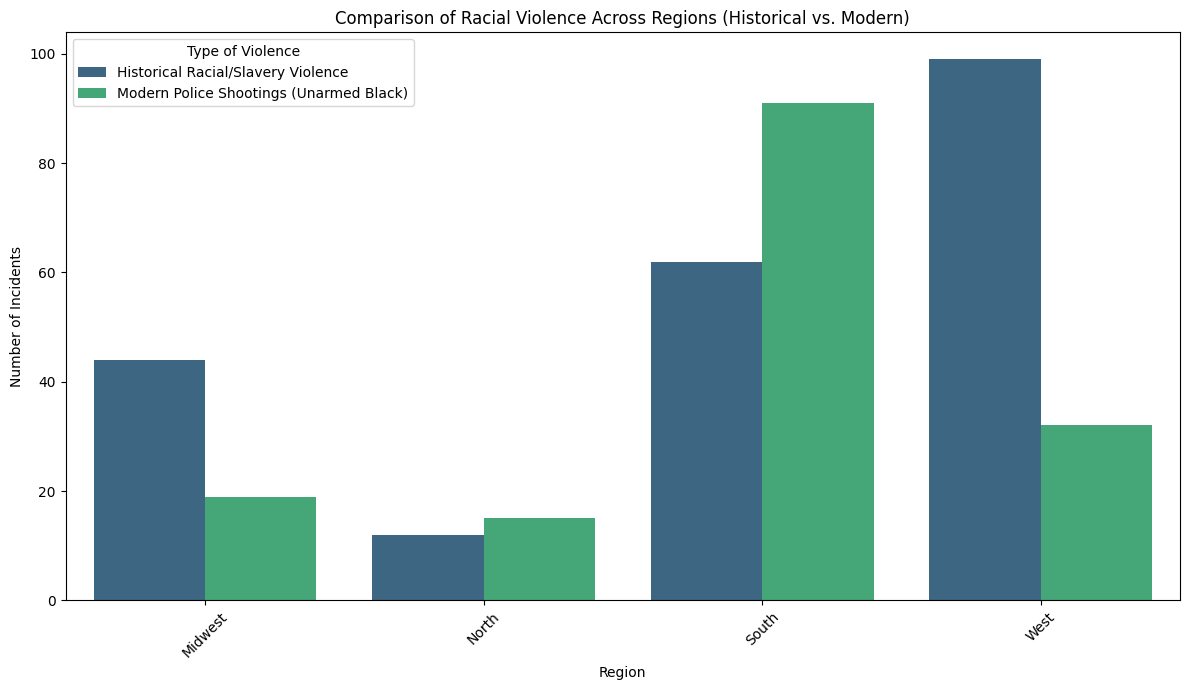

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

historical_violence = violence_counts_per_region.rename(columns={'region': 'Region', 'count': 'Historical Racial/Slavery Violence'})

modern_shootings = ranked_regions_black.rename(columns={'Number of Black Individuals Shot': 'Modern Police Shootings (Unarmed Black)'})

combined_violence = pd.merge(historical_violence, modern_shootings, on='Region', how='outer').fillna(0)

combined_violence_melted = combined_violence.melt(id_vars='Region', var_name='Type of Violence', value_name='Count')

plt.figure(figsize=(12, 7))
sns.barplot(x='Region', y='Count', hue='Type of Violence', data=combined_violence_melted, palette='viridis')
plt.title('Comparison of Racial Violence Across Regions (Historical vs. Modern)')
plt.xlabel('Region')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This chart shows the regional distribution and changes in racial violence between the broader historical period (1783-1865) and more recent police shooting data (that *may* have been racially motivated), adding to the project's overall findings. I was surprised by both the increase in the South, as I previously assumed that racially motivated crime would be much more prevalent during times of slavery, and the drastic decrease in racial violence in the West. However, it is still important to note that the historical period covers a wide time range, and therefore there may have also been fluctuations in racial violence throughout that range that are not visible in my visualization. Furthermore, not all instances of extralegal violence were included in my dataset.